In [2]:
import matplotlib.pyplot as plt

import pydpeet as eet

OCVs are Importend for Analyzing Materials, Ageeing and for Parametrisiation of Models. Here the Funtion from [Squences](Tutorial_02_Sequence.ipynb) is used to automatically extract incremntall OCVs from Lab-Data and analyze it through DVA and ICA

In [3]:
Data = eet.read(config="neware_8_0_0_516", input_path=r"..\..\res\raw\Cal_Ageing_Checkup3.xlsx")

In [6]:
LGM50LT = eet.BatteryConfig(
    c_ref=4.75,
    max_voltage=4.2,
    min_voltage=2.5,
)

In [7]:
Data.head()

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A]
0.0,20240419100603-CheckUp-1-6-AM23NMC00009.xlsx U...,0,3.5353,1.4396,30.1,0.0,2024-04-19 10:06:03,None,None,None,None
1.0,None,0,3.5368,1.4397,30.1,1.0,2024-04-19 10:06:04,None,None,None,None
2.0,None,0,3.5379,1.4398,30.1,2.0,2024-04-19 10:06:05,None,None,None,None
3.0,None,0,3.5388,1.4398,29.9,3.0,2024-04-19 10:06:06,None,None,None,None
4.0,None,0,3.5396,1.4399,29.9,4.0,2024-04-19 10:06:07,None,None,None,None


In [8]:
OCVs = eet.extract_ocv_iocv(df=Data, config=LGM50LT, visualize=False)

C:\Users\Anton\Nextcloud\Organisation\Arbeit\Projekte\PyDPEET\pydpeet_dev\pydpeet\src\pydpeet\process\analyze\soc.py:217: UserWarning: Column 'Capacity[Ah]' missing, adding with function add_capacity.
  warnings.warn("Column 'Capacity[Ah]' missing, adding with function add_capacity.")


In [9]:
OCVs[0].head()

,Test_Time[s],Voltage[V],Current[A],Power[W],ID,Power[W],Meta_Data,Step_Count,Temperature[°C],Date_Time,...,Length,Min,Max,Avg,Type,Direction,Slope,Capacity[Ah],SOC,iOCV_type
44008.0,44002.6,4.1934,0.0,0.0,9,0.0,None,5.0,25.7,2024-04-19 22:19:24,...,899.0,0.0,0.0,0.0,Rest,Neutral,0.0,NaN,1.0,Discharge
44516.0,44508.1,4.1683,0.0,0.0,11,0.0,None,7.0,25.9,2024-04-19 22:27:50,...,359.0,0.0,0.0,0.0,Rest,Neutral,0.0,NaN,1.0,Discharge
45024.0,45013.6,4.1500,0.0,0.0,13,0.0,None,9.0,25.7,2024-04-19 22:36:16,...,359.0,0.0,0.0,0.0,Rest,Neutral,0.0,NaN,1.0,Discharge
45532.0,45519.1,4.1361,0.0,0.0,15,0.0,None,11.0,25.7,2024-04-19 22:44:41,...,359.0,0.0,0.0,0.0,Rest,Neutral,0.0,NaN,1.0,Discharge
46040.0,46024.6,4.1252,0.0,0.0,17,0.0,None,13.0,25.7,2024-04-19 22:53:07,...,359.0,0.0,0.0,0.0,Rest,Neutral,0.0,NaN,1.0,Discharge


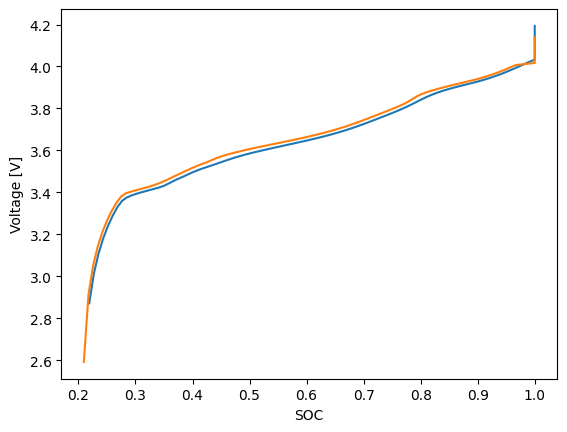

In [10]:
fig, ax = plt.subplots()

for ocv in OCVs:
    ax.plot(ocv["SOC"], ocv["Voltage[V]"], linestyle="-")
    ax.set_xlabel("SOC")
    ax.set_ylabel("Voltage [V]")